In [12]:
import pandas as pd

In [13]:
df = pd.read_csv("dataset.csv")

In [14]:
queries = df['query'].values
labels = df['label'].values

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_temp, y_train, y_temp = train_test_split(
    queries,
    labels,
    test_size=0.3,
    stratify=labels,
    random_state=42
)

In [17]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [29]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    lowercase=True,
    stop_words="english"
)

In [ ]:
pipeline = Pipeline([
    ("tfidf", vectorizer),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

In [20]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

y_val_pred = pipeline.predict(X_val)

print(classification_report(y_val, y_val_pred))
print(confusion_matrix(y_val, y_val_pred))

              precision    recall  f1-score   support

         llm       0.89      0.96      0.92        56
      search       0.96      0.89      0.92        62

    accuracy                           0.92       118
   macro avg       0.93      0.93      0.92       118
weighted avg       0.93      0.92      0.92       118

[[54  2]
 [ 7 55]]


In [22]:
y_test_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))

              precision    recall  f1-score   support

         llm       0.82      0.96      0.89        56
      search       0.96      0.81      0.88        63

    accuracy                           0.88       119
   macro avg       0.89      0.89      0.88       119
weighted avg       0.89      0.88      0.88       119

[[54  2]
 [12 51]]


In [23]:
probs = pipeline.predict_proba(X_test)
max_probs = probs.max(axis=1)

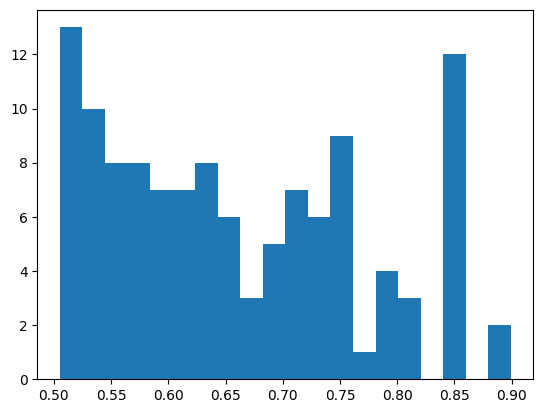

In [24]:
import matplotlib.pyplot as plt
plt.hist(max_probs, bins=20)
plt.show()

In [28]:
import pickle

with open("query_router.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("Model saved successfully.")

Model saved successfully.


In [35]:
import json
import numpy as np

vectorizer = pipeline.named_steps["tfidf"]
clf = pipeline.named_steps["clf"]   # logistic regression

export = {
    "vocab": {k: int(v) for k, v in vectorizer.vocabulary_.items()},
    "idf": vectorizer.idf_.tolist(),
    "weights": clf.coef_[0].tolist(),
    "bias": float(clf.intercept_[0])
}

with open("../extension/model.json", "w") as f:
    json.dump(export, f)